# ALTRA Olink Clustering: Aims 1-2

In [1]:
quiet_library <- function(...){
    suppressPackageStartupMessages(library(...))
}

In [2]:
quiet_library(hise)
quiet_library(purrr)
quiet_library(dplyr)
quiet_library(tidyr)
quiet_library(tibble)
quiet_library(forcats)
quiet_library(stats)
quiet_library(qvalue)
quiet_library(ggplot2)
quiet_library(ggrepel)
quiet_library(factoextra)
quiet_library(cluster)
quiet_library(ComplexHeatmap)
quiet_library(circlize)
quiet_library(RColorBrewer)

In [3]:
if(!dir.exists("/home/workspace/temp/output")) {
    dir.create("/home/workspace/temp/output")
}

outFiles <- list()

## Functions

In [4]:
# function to calculate fold change in protein abundance between clusters

addFC <- function(df) {
    
    a <- df %>%
        group_by(OlinkID, 
                 Cluster) %>%
        summarise(median = median(NPX_Final)) %>%
        ungroup() %>%
        pivot_wider(names_from = Cluster, 
                    values_from = median) %>%
        mutate(log2FC = .[[last(clusters_of_interest)]] - .[[first(clusters_of_interest)]],
               direction = ifelse(log2FC > 0, 
                                  'up', 
                                  'down')) %>%
        select(OlinkID,
               log2FC,
               direction)
    
    final <- df %>%
        left_join(a, by = 'OlinkID')
            
}

In [5]:
# function to perform Wilcoxon text on protein abundance changes

wcx <- function(df, id) {
    
    a <- df %>%
        filter(OlinkID == id)
    
    fit <- wilcox.test(NPX_Final ~ Cluster, 
                       data = a, 
                       alternative = 'two.sided', 
                       paired = FALSE, 
                       exact = FALSE)
    
    fitSummary <- as.data.frame(fit$p.value) %>%
        rename(pval = `fit$p.value`) %>%
        mutate(OlinkID = id, 
               Assay = df$Assay[match(OlinkID, 
                                      table = df$OlinkID)],
               Assay_OID = df$Assay_OID[match(OlinkID, 
                                              table = df$OlinkID)],
               UniProt = df$UniProt[match(OlinkID, 
                                          table = df$OlinkID)],
               UniProt_OID = df$UniProt_OID[match(OlinkID, 
                                                  table = df$OlinkID)])
  
}

In [6]:
# function to perform q-value adjustment

wcxQ <- function(df) {
    
    fitDF <- bind_rows(df)
    
    q <- qvalue(fitDF$pval)
    
    final <- fitDF %>%
        mutate(qval = q$qvalues) %>%
        arrange(qval)
    
}

In [7]:
# Function to plot manuscript figures

manuBoxplot <- function(df, poi, cols) {

    a <- df %>%
        filter(UniProt %in% poi)

    ggplot(a, aes(x = Cluster, 
                  y = NPX_Final)) + 
        geom_boxplot(outlier.shape = NA) + 
        geom_jitter(position = position_jitter(0.2), 
                    size = 2.5, 
                    aes(colour = RAstatus)) + 
        facet_wrap(~as.factor(Assay), 
                   scales = 'free', 
                   ncol = cols) + 
        scale_colour_manual(breaks = c('ALTRA_healthy', 
                                       'non_converter',
                                       'converter',
                                       'early_RA'),
                            labels = c('CON1', 
                                       'NONC',
                                       'CONV',
                                       'ERA'),
                            values = c('#4C8CBD',
                                       '#FFCD70',
                                       '#FF540A',
                                       '#840032'), 
                            name = 'Status') + 
        scale_x_discrete(breaks = c('1', 
                                    '6'),
                         labels = c('C1', 
                                    'C6'), 
                         limits = c('1', 
                                    '6')) + 
        theme_bw() + 
        labs(y = 'Log2 normalized protein expression') + 
        theme(plot.title = element_text(size=12, face='bold', hjust=0.5), 
             #legend.position = c(0.85, 0.75),
             #legend.background = element_rect(colour = 'black', size = 0.5),
             legend.text = element_text(size=12), 
             legend.title = element_text(size=12),
             strip.text.x = element_text(size=14, face='bold'),
             axis.text.y = element_text(size=12),
             axis.text.x = element_text(size=12), 
             axis.title.y = element_text(size=12), 
             axis.title.x = element_text(size=12), 
             panel.grid.major = element_blank(),
             panel.grid.minor = element_blank())

}

## Read in baseline ARI olink data

In [8]:
# from IDE for ALTRA Olink Data for Aim 1: CON | ARI (No Subject Metadata) 2024-12-18

a1_uuid <- 'cc6d77a7-7299-42a8-a0dc-b7edaf056c67' # vadof-pofus-pigip/2024-12-18_Olink_altraHCvARI_noMeta.csv

In [9]:
a1_file <- cacheFiles(list(a1_uuid))

a1 <- read.csv(a1_file, 
               header = T, 
               stringsAsFactors = F)

nrow(a1)

[1] "downloading fileID cc6d77a7-7299-42a8-a0dc-b7edaf056c67"


[1] 108283

## Read in Aim 1 HC1|ARI differential proteins

In [10]:
# from IDE for ALTRA Olink Results Aim 1: CON | ARI 2024-10-22

ari_dap_uuid <- '2455b335-7f8f-4839-9145-752cabfe319c' # zahin-totok-popin/2024-10-22_Risk_lm_riskVariable.csv

In [11]:
ari_dap_file <- cacheFiles(list(ari_dap_uuid))

ari_dap <- read.csv(ari_dap_file, 
                header = T, 
                stringsAsFactors = F)

nrow(ari_dap)

[1] "downloading fileID 2455b335-7f8f-4839-9145-752cabfe319c"


[1] 1327

In [12]:
ari_dap2 <- ari_dap %>%
    filter(qval <= 0.1) %>%
    select(OlinkID, 
           qval) %>%
    distinct(OlinkID, .keep_all = T)

nrow(ari_dap2)

[1] 272

## Read in baseline ERA olink data

In [13]:
# from IDE for ALTRA Olink Data for Aim 2 (CON | ERA) 2024-10-22

a2_uuid <- '78d58a68-f030-4ef5-b60a-4aedb2a5ad85' # tafug-kasir-kasap/2024-10-22_Olink_altraHCvERA.csv

In [14]:
a2_file <- cacheFiles(list(a2_uuid))

a2 <- read.csv(a2_file, 
               header = T, 
               stringsAsFactors = F)

nrow(a2)

[1] "downloading fileID 78d58a68-f030-4ef5-b60a-4aedb2a5ad85"


[1] 85294

In [15]:
terms <- c('sample', 'subject', 'cohort', 'age', 'time', 'bmi', 'BMI', 'days', 'Status', 'aim')

keep_a2 <- a2 %>%
    select(SampleID,
           sample.sampleKitGuid,
           !contains(terms))

nrow(keep_a2)

[1] 85294

## Read in Aim 2 HC1|ERA differential proteins

In [16]:
# from IDE for ALTRA Olink Results Aim 2: CON | ERA 2025-02-07

era_dap_uuid <- '74750863-0db2-4279-868e-6c5d8bb35db3' # binaj-dasoh-finom/2025-02-07_ERA_lm_EraVariable.csv

In [17]:
era_dap_file <- cacheFiles(list(era_dap_uuid))

era_dap <- read.csv(era_dap_file, 
                header = T, 
                stringsAsFactors = F)

nrow(era_dap)

[1] "downloading fileID 74750863-0db2-4279-868e-6c5d8bb35db3"


[1] 1342

In [18]:
era_dap2 <- era_dap %>%
    filter(qval <= 0.1) %>%
    select(OlinkID, 
           qval) %>%
    distinct(OlinkID, .keep_all = T)

nrow(era_dap2)

[1] 20

## Read in metadata

In [19]:
meta_uuid <- '32b8bb9c-4834-4e5c-9b3a-7939b3b7f057'

In [20]:
meta_file <- cacheFiles(list(meta_uuid))

meta <- read.csv(meta_file, 
                 header = T, stringsAsFactors = F)

nrow(meta)

[1] "downloading fileID 32b8bb9c-4834-4e5c-9b3a-7939b3b7f057"


[1] 157

In [21]:
conv <- c('CU1003', 'CU1007', 'CU1009', 'CU1010', 'CU1015', 'CU1021', 'CU1029', 
          'CU1033', 'CU1037', 'CU1039', 'CU1044', 'CU1050', 'CU1052', 'CU1053', 
          'SD1003', 'SD1007', 'CU1002')

outCols <- c('Status_Long')

In [22]:
meta2 <- meta %>%
    select(-any_of(outCols)) %>%
    filter(Status_Xsec %in% c('ALTRA_healthy', 'at_risk') | 
           Status_Xsec == 'early_RA' & !subject.subjectGuid %in% conv) %>%
    mutate(RAstatus = ifelse(Status_Xsec == 'ALTRA_healthy' | Status_Xsec == 'early_RA', 
                             Status_Xsec, 
                             ifelse(Status_Xsec == 'at_risk' & subject.subjectGuid %in% conv, 
                                    'converter', 
                                    'non_converter')))

In [23]:
table(meta2$RAstatus, meta2$Status_Xsec)

               
                ALTRA_healthy at_risk early_RA
  ALTRA_healthy            38       0        0
  converter                 0      15        0
  early_RA                  0       0       11
  non_converter             0      30        0

## Merge olink data and metadata

In [24]:
risk <- a1 %>%
    inner_join(meta2, by = 'sample.sampleKitGuid')

nrow(risk)

[1] 108283

In [25]:
era <- keep_a2 %>%
    inner_join(meta2, by = 'sample.sampleKitGuid') %>%
    filter(RAstatus == 'early_RA')

nrow(era)

[1] 14727

In [26]:
all <- risk %>%
    bind_rows(era)

nrow(all)

New names:
• `record_id...112` -> `record_id...146`
• `record_id...120` -> `record_id...154`
• `record_id...114` -> `record_id...158`
• `record_id...123` -> `record_id...159`
New names:
• `record_id...112` -> `record_id...146`
• `record_id...120` -> `record_id...154`
• `record_id...114` -> `record_id...158`
• `record_id...123` -> `record_id...159`


[1] 123010

In [27]:
qc <- all %>%
    distinct(sample.sampleKitGuid, .keep_all = T)


table(qc$Status_Xsec, qc$cohort.cohortGuid)

               
                CU1 SD1
  ALTRA_healthy  31   6
  at_risk        40   5
  early_RA        9   2

In [28]:
all <- all %>%
    unite(col = 'Subject_Sample', 
          c('subject.subjectGuid', 'sample.sampleKitGuid'),
          sep = '_', 
          remove = FALSE)


head(all)
nrow(all)

,SampleID,Subject_Sample,sample.sampleKitGuid,Index,Assay_OID,UniProt_OID,OlinkID,UniProt,Assay,MissingFreq,⋯,record_id...158,record_id...159,BMI,CMV_Status_Subj,CMV_Value_Subj,anti_ccp3_finalCombined,days_to_conversion,age_conv,bmi_conv,RAstatus
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,⋯,<lgl>,<lgl>,<dbl>,<chr>,<dbl>,<int>,<int>,<int>,<dbl>,<chr>
1,PL00065-01,CU1013_KT00065,KT00065,31,TNFRSF1B_OID21145,P20333_OID21145,OID21145,P20333,TNFRSF1B,0.0000000,⋯,NA,NA,22.83863,Negative,0.038,269,NA,NA,NA,non_converter
2,PL00065-01,CU1013_KT00065,KT00065,31,PAMR1_OID21153,Q6UXH9_OID21153,OID21153,Q6UXH9,PAMR1,0.0000000,⋯,NA,NA,22.83863,Negative,0.038,269,NA,NA,NA,non_converter
3,PL00065-01,CU1013_KT00065,KT00065,31,IL7R_OID21136,P16871_OID21136,OID21136,P16871,IL7R,0.0000000,⋯,NA,NA,22.83863,Negative,0.038,269,NA,NA,NA,non_converter
4,PL00065-01,CU1013_KT00065,KT00065,31,PRTFDC1_OID20867,Q9NRG1_OID20867,OID20867,Q9NRG1,PRTFDC1,0.3784615,⋯,NA,NA,22.83863,Negative,0.038,269,NA,NA,NA,non_converter
5,PL00065-01,CU1013_KT00065,KT00065,31,SLC39A14_OID20852,Q15043_OID20852,OID20852,Q15043,SLC39A14,0.0000000,⋯,NA,NA,22.83863,Negative,0.038,269,NA,NA,NA,non_converter
6,PL00065-01,CU1013_KT00065,KT00065,31,SPINK5_OID21148,Q9NQ38_OID21148,OID21148,Q9NQ38,SPINK5,0.0000000,⋯,NA,NA,22.83863,Negative,0.038,269,NA,NA,NA,non_converter


[1] 123010

In [29]:
# update assay names for repeat assays

all <- all %>%
    mutate(Assay = ifelse(UniProt %in% c('P01375',
                                         'P10145', 
                                         'P05231'), 
                          Assay_OID, 
                          Assay))

## k-means Clustering on significantly changing proteins

In [30]:
# combine ari + era differential proteins

sigList <- ari_dap2 %>%
    bind_rows(era_dap2) %>%
    arrange(qval) %>% # force order for next step
    distinct(OlinkID, .keep_all = T)

nrow(sigList)

[1] 280

In [31]:
# filter main df

sigDEPs <- sigList %>%
    left_join(all, by = 'OlinkID')


head(sigDEPs)
nrow(sigDEPs)

,OlinkID,qval,SampleID,Subject_Sample,sample.sampleKitGuid,Index,Assay_OID,UniProt_OID,UniProt,Assay,⋯,record_id...158,record_id...159,BMI,CMV_Status_Subj,CMV_Value_Subj,anti_ccp3_finalCombined,days_to_conversion,age_conv,bmi_conv,RAstatus
,<chr>,<dbl>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,⋯,<lgl>,<lgl>,<dbl>,<chr>,<dbl>,<int>,<int>,<int>,<dbl>,<chr>
1,OID20427,2.144259e-09,PL00065-01,CU1013_KT00065,KT00065,31,IL1B_OID20427,P01584_OID20427,P01584,IL1B,⋯,NA,NA,22.83863,Negative,0.038,269,NA,NA,NA,non_converter
2,OID20427,2.144259e-09,PL00087-01,CU1030_KT00087,KT00087,63,IL1B_OID20427,P01584_OID20427,P01584,IL1B,⋯,NA,NA,36.07157,Negative,0.085,52,NA,NA,NA,non_converter
3,OID20427,2.144259e-09,PL00221-01,CU1018_KT00221,KT00221,66,IL1B_OID20427,P01584_OID20427,P01584,IL1B,⋯,NA,NA,22.86253,Positive,2.917,56,NA,NA,NA,non_converter
4,OID20427,2.144259e-09,PL00073-01,CU1022_KT00073,KT00073,67,IL1B_OID20427,P01584_OID20427,P01584,IL1B,⋯,NA,NA,21.64304,Negative,0.297,64,NA,NA,NA,non_converter
5,OID20427,2.144259e-09,PL00056-01,CU1007_KT00056,KT00056,73,IL1B_OID20427,P01584_OID20427,P01584,IL1B,⋯,NA,NA,25.94834,Negative,0.145,2544,-632,44,26.19498,converter
6,OID20427,2.144259e-09,PL00211-01,CU1026_KT00211,KT00211,87,IL1B_OID20427,P01584_OID20427,P01584,IL1B,⋯,NA,NA,23.33991,Negative,0.096,52,NA,NA,NA,non_converter


[1] 25854

In [32]:
# Optimal columns

DEP <- sigDEPs %>%
    select(Subject_Sample, # some subjects have multiple samples
           Assay_OID, 
           NPX_Final) %>%
    pivot_wider(names_from = Subject_Sample, 
                values_from = NPX_Final) %>%
    column_to_rownames(var = 'Assay_OID') %>%
    drop_na() %>%
    as.matrix()

DEP <- t(scale(t(DEP)))

head(DEP)

,CU1013_KT00065,CU1030_KT00087,CU1018_KT00221,CU1022_KT00073,CU1007_KT00056,CU1026_KT00211,CU1002_KT00058,CU1031_KT00088,CU1023_KT00086,CU1004_KT00077,⋯,CU1012_KT00072,CU1032_KT00447,CU1043_KT00474,SD1012_KT00777,CU1059_KT02140,CU1058_KT02141,CU1056_KT02139,SD1014_KT00778,CU1068_KT02981,CU1093_KT04625
IL1B_OID20427,-0.1310946,0.86950017,0.07330985,-0.55471024,1.1328906,-0.3518707,0.805217488,1.49439039,0.133138483,0.3423581,⋯,-0.31647912,-0.59696346,0.1720211,1.1830889,1.4474424,1.25290902,0.4618950,2.2101672,-2.2819160,-1.2962482
CCL28_OID20569,0.7855961,0.41002646,0.54662901,0.53614799,-0.1297457,0.7740670,-0.005545734,0.21787454,1.177236669,0.2898442,⋯,-0.48051034,0.42784419,1.4797886,1.1207265,2.8193495,1.25505820,-0.5323040,1.3764633,-0.6261964,-2.5681536
SCRN1_OID20542,0.7241652,-0.35995365,0.27317449,0.06740784,0.1717609,-0.8501757,-0.513600278,0.23326480,-0.002349309,0.7304965,⋯,0.60511452,-0.09867523,0.5976527,1.1688247,0.2611903,0.56124779,1.2630025,0.5443455,-1.8432824,-0.6810401
HLA-DRA_OID20520,1.0576722,0.38184653,-0.10220840,-0.04797458,0.3348439,0.2826348,-0.090493892,0.84869125,0.069604346,0.4641373,⋯,1.04190828,0.77305315,0.4567615,-0.1140675,0.2485036,0.93604386,0.4285599,2.7157086,0.7924327,-1.9606206
TIA1_OID20068,0.4586689,-0.03336033,-0.16486936,-0.37747165,-0.1662169,-0.2549201,-0.266731379,-0.05072048,0.131997002,0.5696470,⋯,0.00112214,-0.20569344,0.1102770,2.1784724,0.9049197,0.04254074,0.5338566,2.6281318,-0.9199959,-1.1607391
DPEP2_OID21305,1.2790381,0.84569506,1.78680357,0.95098173,0.2737122,-0.3104671,0.699090217,1.88536982,1.418424679,1.5147508,⋯,0.03849725,-0.19273517,-0.5053594,-1.5649466,-1.0235789,-3.14101085,-0.3515363,0.6343750,-0.8381450,-1.0636526


In [33]:
# Calculate gap statistic

set.seed(905)

gapStat <- cluster::clusGap(DEP, 
                            FUN = kmeans, 
                            K.max = 10, 
                            B = 100, 
                            iter.max = 20)

#### Visualization: Optimal column cluster number

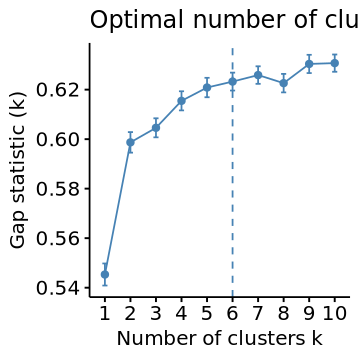

In [34]:
options(repr.plot.width = 3, repr.plot.height = 3) # default 7x7

p <- fviz_gap_stat(gapStat)

print(p)

In [35]:
ggsave(filename = 'GapStatistic_Cols.pdf',
       path = '/home/workspace/temp/output/',
       p,
       device = 'pdf', 
       width = 2.5, 
       height = 2.5, 
       units = 'in')

In [36]:
# Optimal rows - transpose above matrix

DEP <- t(DEP)

head(DEP)

,IL1B_OID20427,CCL28_OID20569,SCRN1_OID20542,HLA-DRA_OID20520,TIA1_OID20068,DPEP2_OID21305,IQGAP2_OID21361,LAP3_OID20436,RAB37_OID20425,FGF19_OID20715,⋯,PSME1_OID20969,MAX_OID20877,ERP44_OID21338,LEFTY2_OID21454,LILRB4_OID20429,CKAP4_OID20617,JCHAIN_OID20494,S100A16_OID20878,ARHGAP25_OID21255,GDF2_OID20202
CU1013_KT00065,-0.13109462,0.7855961,0.72416523,1.05767224,0.45866890,1.2790381,1.19172340,0.2425874,1.36032251,-0.0876733,⋯,0.2194520,0.5079936,1.107011e+00,0.49545298,0.05820001,-0.17254080,0.3320986,0.5025635,0.4204018,1.1251597
CU1030_KT00087,0.86950017,0.4100265,-0.35995365,0.38184653,-0.03336033,0.8456951,0.71991808,-0.8683637,0.11114013,2.2114993,⋯,-1.2276950,-0.1124110,3.015152e-01,0.62395548,2.30523237,-0.03595266,-0.3560342,0.7791405,-0.2810521,0.5799285
CU1018_KT00221,0.07330985,0.5466290,0.27317449,-0.10220840,-0.16486936,1.7868036,0.40047230,-0.3052109,-0.09717927,-0.0935372,⋯,-0.1202697,-0.5555676,1.198070e+00,0.52506928,1.58307032,0.31033846,0.7815531,0.4669292,0.1593375,0.4144603
CU1022_KT00073,-0.55471024,0.5361480,0.06740784,-0.04797458,-0.37747165,0.9509817,-0.25699970,-0.4554080,1.96846568,0.7672303,⋯,-0.4523167,-1.0500155,-5.615069e-05,0.57587547,-0.29634094,0.12848875,0.9005299,0.1740319,0.2958472,1.3617813
CU1007_KT00056,1.13289061,-0.1297457,0.17176093,0.33484388,-0.16621695,0.2737122,0.05446338,0.1578490,0.20622505,0.2430680,⋯,-0.7649510,-0.3929743,5.384641e-01,-0.75214884,2.96612424,0.14750396,1.7526937,5.2100688,0.9818708,0.2640157
CU1026_KT00211,-0.35187071,0.7740670,-0.85017572,0.28263479,-0.25492014,-0.3104671,-0.77312278,0.2010263,-0.21681946,0.2847279,⋯,-1.8597355,-1.2985583,-1.102554e+00,0.08615334,0.35164289,-0.81263034,-0.4751318,0.5045915,-0.6315011,1.1554156


In [37]:
# Calculate gap statistic

set.seed(905)

gapStat <- cluster::clusGap(DEP, 
                            FUN = kmeans, 
                            K.max = 10, 
                            B = 100, 
                            iter.max = 20)

#### Visualization: Optimal row cluster number

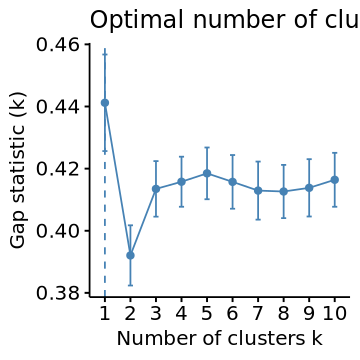

In [38]:
options(repr.plot.width = 3, repr.plot.height = 3) # default 7x7

p <- fviz_gap_stat(gapStat)

print(p)

In [39]:
ggsave(filename = 'GapStatistic_Rows.pdf', 
       path = '/home/workspace/temp/output/',
       p,
       device = 'pdf', 
       width = 2.5, 
       height = 2.5, 
       units = 'in')

#### Visualization: k-means heatmap

In [40]:
# Column annotations. Must be in same order as data matrix.
# As long as input order is preserved between annotation and matrix, it will be the same after the algorithm clusters the data

anno <- sigDEPs %>% 
    distinct(Subject_Sample, .keep_all = T) # unique df

colAnn <- data.frame(Group = anno$Status_Xsec, 
                     Status = anno$RAstatus)

head(colAnn)


# Annotation colours
annotColours <- list(Group = c('ALTRA_healthy' = '#4C8CBD',
                               'at_risk' = '#F59F00', 
                               'early_RA' = '#840032'), 
                     Status = c('ALTRA_healthy' = '#4C8CBD', 
                                'converter' = '#FF540A', 
                                'non_converter' = '#FFCD70', 
                                'early_RA' = '#840032'))


# Annotation function
colHA <- HeatmapAnnotation(df = colAnn, 
                           col = annotColours)


# Standardized data matrix. Must be in same order as annotations.
DEP <- sigDEPs %>%
    select(Subject_Sample, 
           Assay, 
           NPX_Final) %>%
    pivot_wider(names_from = Subject_Sample, 
                values_from = NPX_Final) %>%
    column_to_rownames(var = 'Assay') %>%
    drop_na() %>%
    as.matrix()

DEP <- t(scale(t(DEP)))

head(DEP)


# Set scale limits. Requires long format data
longDEP <- DEP %>%
    as.data.frame() %>%
    rownames_to_column(var = 'Assay') %>%
    pivot_longer(cols = !Assay, 
                 names_to = 'Subject_Sample', 
                 values_to = 'NPX', 
                 values_drop_na = TRUE)

limit <- range(longDEP$NPX)
limit <- c(ceiling(limit[1]), floor(limit[2]))
limit <- min(abs(limit))


# plot

options(repr.plot.width = 10, repr.plot.height = 6) # default 7x7

set.seed(905)

pdf('/home/workspace/temp/output/kmeans_heatmap_with_converters.pdf', 
    width = 8, 
    height = 6, 
    colormodel = 'cmyk')

hm <- Heatmap(matrix = DEP, 
              col = colorRamp2(c(min(DEP), # min = -5.18
                                 seq(from = -1*limit, 
                                     to = limit, 
                                     length.out = 9),
                                 max(DEP)), # max = 8.02
                               rev(brewer.pal(n=11, name = 'RdBu'))),
              na_col = 'black',
              #rect_gp = gpar(col = "white", lwd = 0.5),
              name = 'Z-score\nNPX', 
              #cluster_columns = FALSE,
              clustering_distance_rows = "euclidean",
              clustering_method_rows = "complete",
              clustering_distance_columns = "euclidean",
              clustering_method_columns = "complete",
              show_row_names = FALSE, 
              show_column_names = FALSE,
              column_km = 6,
              column_km_repeats = 100, 
              row_km = 1, 
              row_km_repeats = 100, 
              top_annotation = colHA)

hm <- draw(hm)

dev.off()

,Group,Status
,<chr>,<chr>
1,at_risk,non_converter
2,at_risk,non_converter
3,at_risk,non_converter
4,at_risk,non_converter
5,at_risk,converter
6,at_risk,non_converter


,CU1013_KT00065,CU1030_KT00087,CU1018_KT00221,CU1022_KT00073,CU1007_KT00056,CU1026_KT00211,CU1002_KT00058,CU1031_KT00088,CU1023_KT00086,CU1004_KT00077,⋯,CU1012_KT00072,CU1032_KT00447,CU1043_KT00474,SD1012_KT00777,CU1059_KT02140,CU1058_KT02141,CU1056_KT02139,SD1014_KT00778,CU1068_KT02981,CU1093_KT04625
IL1B,-0.1310946,0.86950017,0.07330985,-0.55471024,1.1328906,-0.3518707,0.805217488,1.49439039,0.133138483,0.3423581,⋯,-0.31647912,-0.59696346,0.1720211,1.1830889,1.4474424,1.25290902,0.4618950,2.2101672,-2.2819160,-1.2962482
CCL28,0.7855961,0.41002646,0.54662901,0.53614799,-0.1297457,0.7740670,-0.005545734,0.21787454,1.177236669,0.2898442,⋯,-0.48051034,0.42784419,1.4797886,1.1207265,2.8193495,1.25505820,-0.5323040,1.3764633,-0.6261964,-2.5681536
SCRN1,0.7241652,-0.35995365,0.27317449,0.06740784,0.1717609,-0.8501757,-0.513600278,0.23326480,-0.002349309,0.7304965,⋯,0.60511452,-0.09867523,0.5976527,1.1688247,0.2611903,0.56124779,1.2630025,0.5443455,-1.8432824,-0.6810401
HLA-DRA,1.0576722,0.38184653,-0.10220840,-0.04797458,0.3348439,0.2826348,-0.090493892,0.84869125,0.069604346,0.4641373,⋯,1.04190828,0.77305315,0.4567615,-0.1140675,0.2485036,0.93604386,0.4285599,2.7157086,0.7924327,-1.9606206
TIA1,0.4586689,-0.03336033,-0.16486936,-0.37747165,-0.1662169,-0.2549201,-0.266731379,-0.05072048,0.131997002,0.5696470,⋯,0.00112214,-0.20569344,0.1102770,2.1784724,0.9049197,0.04254074,0.5338566,2.6281318,-0.9199959,-1.1607391
DPEP2,1.2790381,0.84569506,1.78680357,0.95098173,0.2737122,-0.3104671,0.699090217,1.88536982,1.418424679,1.5147508,⋯,0.03849725,-0.19273517,-0.5053594,-1.5649466,-1.0235789,-3.14101085,-0.3515363,0.6343750,-0.8381450,-1.0636526


png 
  2

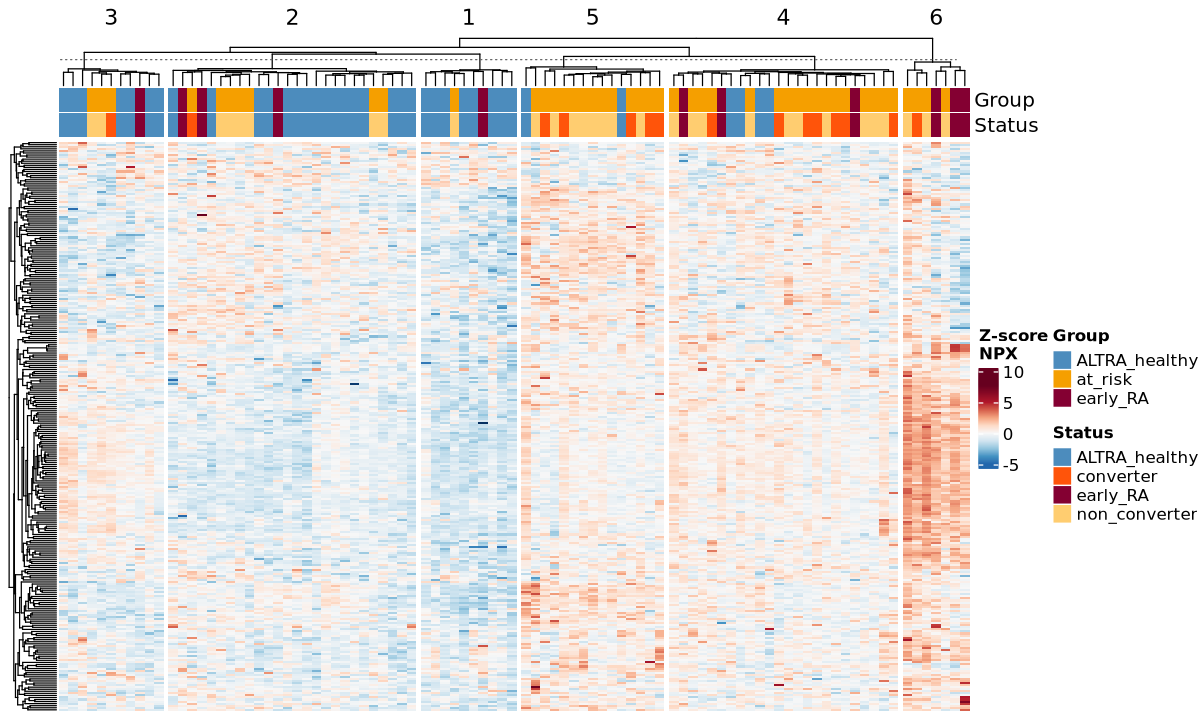

In [41]:
hm

In [42]:
out_kmeansMatrix <- paste0(
    "/home/workspace/temp/output/",
    Sys.Date(),
    "_kmeans_zscore_matrix.csv"
)

write.csv(
    DEP, 
    out_kmeansMatrix,
    row.names = TRUE
)

outFiles <- c(outFiles, out_kmeansMatrix)

#### Visualization: Samples per cluster

In [43]:
# function to extract cluster metadata

generateClusterMetadata <- function(df){

    # extract sample and cluster order from heatmap - results in list of integers
    a <- column_order(df)

    # make into single df
    b <- map_dfr(a, 
                 ~as.data.frame(.x), 
                 .id = 'Cluster') %>%
        rename(Order = '.x')

    # get Status annotations
    c <- colAnn %>%
        mutate(Order = row_number())

    # get Subject annotation
    d <- DEP %>%
        t() %>%
        as.data.frame() %>%
        rownames_to_column(var = 'Subject_Sample') %>%
        select(Subject_Sample) %>%
        mutate(Order = row_number())

    # combine
    e <- b %>%
        left_join(c, by = 'Order') %>%
        left_join(d, by = 'Order')

}

In [44]:
clusterInfo <- generateClusterMetadata(hm)

nrow(clusterInfo)

[1] 93

In [45]:
out_clusterInfo <- paste0(
    "/home/workspace/temp/output/",
    Sys.Date(),
    "_Samples_by_Cluster.csv"
)

write.csv(
    clusterInfo, 
    out_clusterInfo,
    row.names = FALSE
)

outFiles <- c(outFiles, out_clusterInfo)

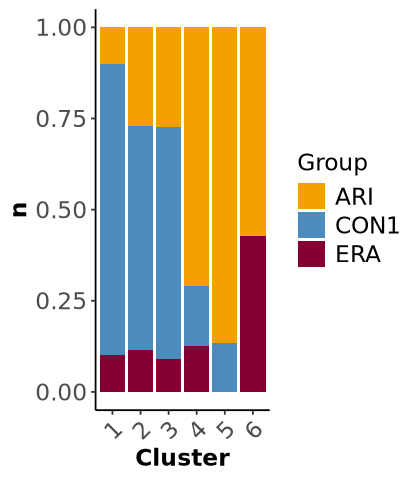

In [46]:
options(repr.plot.width = 3.5, repr.plot.height = 4) # default 7x7

p <- clusterInfo %>%
    mutate(Group = factor(clusterInfo$Group, levels = c('at_risk', 'ALTRA_healthy', 'early_RA'))) %>%
    count(Cluster, Group) %>%
    ggplot(aes(x = Cluster, 
               y = n, 
               fill = Group)) + 
        geom_bar(position = 'fill', 
                 stat = 'identity') + 
        scale_fill_manual(breaks = c('at_risk', 
                                     'ALTRA_healthy', 
                                     'early_RA'),
                          values = c('#F59F00', 
                                     '#4C8CBD', 
                                     '#840032'), 
                          labels = c('ARI', 
                                     'CON1', 
                                     'ERA')) + 
        theme_classic() + 
        theme (plot.title = element_text(size=14, face='bold', hjust=0.5), 
               #legend.position = 'none',
               legend.text = element_text(size = 14),
               legend.title = element_text(size=14),
               axis.text.y = element_text(size = 14),
               axis.text.x = element_text(size = 14, angle = 45, hjust = 1, vjust = 1), 
               axis.title.y = element_text(size = 14, face='bold'), 
               axis.title.x = element_text(size = 14, face = 'bold'))

plot(p)

In [47]:
ggsave(filename = 'GroupsByCluster.pdf', 
       path = '/home/workspace/temp/output/',
       p,
       device = 'pdf', 
       width = 3.5, 
       height = 4, 
       units = 'in')

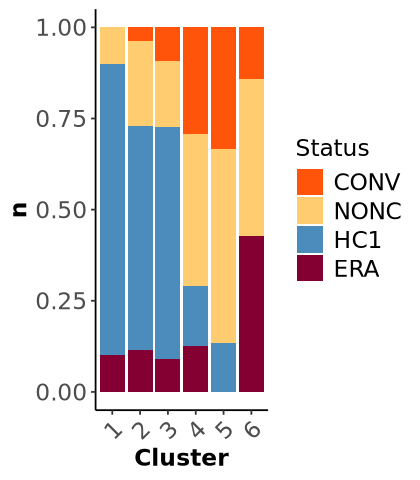

In [48]:
options(repr.plot.width = 3.5, repr.plot.height = 4) # default 7x7

p <- clusterInfo %>%
    mutate(Status = factor(clusterInfo$Status, levels = c('converter', 'non_converter', 'ALTRA_healthy','early_RA'))) %>%
    count(Cluster, Status) %>%
    ggplot(aes(x = Cluster, 
               y = n, 
               fill = Status)) + 
        geom_bar(position = 'fill', 
                 stat = 'identity') + 
        scale_fill_manual(breaks = c('converter', 
                                     'non_converter', 
                                     'ALTRA_healthy', 
                                     'early_RA'),
                          values = c('#FF540A', 
                                     '#FFCD70', 
                                     '#4C8CBD', 
                                     '#840032'), 
                          labels = c('CONV', 
                                     'NONC', 
                                     'HC1', 
                                     'ERA')) + 
        theme_classic() + 
        theme (plot.title = element_text(size=14, face='bold', hjust=0.5), 
               #legend.position = 'none',
               legend.text = element_text(size = 14),
               legend.title = element_text(size=14),
               axis.text.y = element_text(size = 14),
               axis.text.x = element_text(size = 14, angle = 45, hjust = 1, vjust = 1), 
               axis.title.y = element_text(size = 14, face='bold'), 
               axis.title.x = element_text(size = 14, face = 'bold'))

plot(p)

In [49]:
ggsave(filename = 'StatusByCluster.pdf', 
       path = '/home/workspace/temp/output/',
       p,
       device = 'pdf', 
       width = 3.5, 
       height = 4, 
       units = 'in')

#### Calculate C1 vs C6 significance in proteins that were not part of original clustering

In [50]:
clusters_of_interest = c('1', '6')

In [51]:
notClusteredDF <- clusterInfo %>%
    filter(Cluster %in% clusters_of_interest) %>%
    left_join(all, by = 'Subject_Sample') %>%
    mutate(RAstatus = ifelse(subject.subjectGuid %in% conv, 
                             'converter', 
                             ifelse(Status_Xsec == 'at_risk' & !subject.subjectGuid %in% conv, 
                                    'non_converter', 
                                    ifelse(Status_Xsec %in% c('early_RA', 'ALTRA_healthy'), 
                                           Status_Xsec, 
                                           '')))) %>%
    filter(!OlinkID %in% sigDEPs$OlinkID, # remove proteins used to cluster
           OlinkID != 'OID20119') # only has values in C6. manually determined this as it was throwing an error in downstream function



head(notClusteredDF)
nrow(notClusteredDF)

,Cluster,Order,Group,Status,Subject_Sample,SampleID,sample.sampleKitGuid,Index,Assay_OID,UniProt_OID,⋯,record_id...158,record_id...159,BMI,CMV_Status_Subj,CMV_Value_Subj,anti_ccp3_finalCombined,days_to_conversion,age_conv,bmi_conv,RAstatus
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,⋯,<lgl>,<lgl>,<dbl>,<chr>,<dbl>,<int>,<int>,<int>,<dbl>,<chr>
1,1,64,ALTRA_healthy,ALTRA_healthy,CU1101_KT04671,PL04671-001,KT04671,2,NPPB_OID20049,P16860_OID20049,⋯,NA,NA,21.54195,NA,NA,6,NA,NA,NA,ALTRA_healthy
2,1,64,ALTRA_healthy,ALTRA_healthy,CU1101_KT04671,PL04671-001,KT04671,2,CEBPB_OID20052,P17676_OID20052,⋯,NA,NA,21.54195,NA,NA,6,NA,NA,NA,ALTRA_healthy
3,1,64,ALTRA_healthy,ALTRA_healthy,CU1101_KT04671,PL04671-001,KT04671,2,MFAP3_OID20057,P55082_OID20057,⋯,NA,NA,21.54195,NA,NA,6,NA,NA,NA,ALTRA_healthy
4,1,64,ALTRA_healthy,ALTRA_healthy,CU1101_KT04671,PL04671-001,KT04671,2,CTF1_OID20061,Q16619_OID20061,⋯,NA,NA,21.54195,NA,NA,6,NA,NA,NA,ALTRA_healthy
5,1,64,ALTRA_healthy,ALTRA_healthy,CU1101_KT04671,PL04671-001,KT04671,2,VAMP5_OID20071,O95183_OID20071,⋯,NA,NA,21.54195,NA,NA,6,NA,NA,NA,ALTRA_healthy
6,1,64,ALTRA_healthy,ALTRA_healthy,CU1101_KT04671,PL04671-001,KT04671,2,SUSD1_OID20072,Q6UWL2_OID20072,⋯,NA,NA,21.54195,NA,NA,6,NA,NA,NA,ALTRA_healthy


[1] 17729

In [52]:
qc <- notClusteredDF %>%
    distinct(subject.subjectGuid, .keep_all = T)

table(qc$RAstatus, qc$Status_Xsec)

               
                ALTRA_healthy at_risk early_RA
  ALTRA_healthy             8       0        0
  converter                 0       1        0
  early_RA                  0       0        4
  non_converter             0       4        0

In [53]:
# Unique Olink ID's
uniID <- unique(notClusteredDF$OlinkID)

In [54]:
wcxC1C6 <- lapply(uniID, function(id){
    wcx(notClusteredDF, id)
    })


wcxC1C6df <- wcxQ(wcxC1C6)


head(wcxC1C6df)
nrow(wcxC1C6df)

,pval,OlinkID,Assay,Assay_OID,UniProt,UniProt_OID,qval
,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,0.0007603058,OID20072,SUSD1,SUSD1_OID20072,Q6UWL2,Q6UWL2_OID20072,0.002546752
2,0.0007603058,OID20085,IRAG2,IRAG2_OID20085,Q12912,Q12912_OID20085,0.002546752
3,0.0007603058,OID20086,COMT,COMT_OID20086,P21964,P21964_OID20086,0.002546752
4,0.0007603058,OID20091,WASF1,WASF1_OID20091,Q92558,Q92558_OID20091,0.002546752
5,0.0007603058,OID20097,GYS1,GYS1_OID20097,P13807,P13807_OID20097,0.002546752
6,0.0007603058,OID20110,USP8,USP8_OID20110,P40818,P40818_OID20110,0.002546752


[1] 1073

In [55]:
out_wilcoxon_C1_C6 <- paste0(
    "/home/workspace/temp/output/",
    Sys.Date(),
    "_Wilcoxon_C1_C6_proteinsNotClustered.csv"
)

write.csv(
    wcxC1C6df, 
    out_wilcoxon_C1_C6,
    row.names = FALSE
)

outFiles <- c(outFiles, out_wilcoxon_C1_C6)

#### Visualization: Significant cytokines, chemokines, and related
Not part of original clustering <br>
Significance calculated by Wilcoxon ranksum test

In [56]:
pattern <- c('TNF', 'IFN', 'OSM', 'TGF', 'FASL', 'CSF', 'LILRB', 'CXCL', 'CCL')


sig <- wcxC1C6df %>%
    filter(qval <= 0.05)


cyto <- notClusteredDF %>%
    filter(OlinkID %in% sig$OlinkID, 
           grepl(paste0(pattern, collapse = '|'), Assay) | 
           startsWith(Assay, 'IL'))


head(cyto)
nrow(cyto)

,Cluster,Order,Group,Status,Subject_Sample,SampleID,sample.sampleKitGuid,Index,Assay_OID,UniProt_OID,⋯,record_id...158,record_id...159,BMI,CMV_Status_Subj,CMV_Value_Subj,anti_ccp3_finalCombined,days_to_conversion,age_conv,bmi_conv,RAstatus
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,⋯,<lgl>,<lgl>,<dbl>,<chr>,<dbl>,<int>,<int>,<int>,<dbl>,<chr>
1,1,64,ALTRA_healthy,ALTRA_healthy,CU1101_KT04671,PL04671-001,KT04671,2,TNF_OID20074,P01375_OID20074,⋯,NA,NA,21.54195,NA,NA,6,NA,NA,NA,ALTRA_healthy
2,1,64,ALTRA_healthy,ALTRA_healthy,CU1101_KT04671,PL04671-001,KT04671,2,CXCL8_OID20153,P10145_OID20153,⋯,NA,NA,21.54195,NA,NA,6,NA,NA,NA,ALTRA_healthy
3,1,64,ALTRA_healthy,ALTRA_healthy,CU1101_KT04671,PL04671-001,KT04671,2,CXCL5_OID20207,P42830_OID20207,⋯,NA,NA,21.54195,NA,NA,6,NA,NA,NA,ALTRA_healthy
4,1,64,ALTRA_healthy,ALTRA_healthy,CU1101_KT04671,PL04671-001,KT04671,2,TGFBR3_OID20255,Q03167_OID20255,⋯,NA,NA,21.54195,NA,NA,6,NA,NA,NA,ALTRA_healthy
5,1,64,ALTRA_healthy,ALTRA_healthy,CU1101_KT04671,PL04671-001,KT04671,2,TNFSF13B_OID20272,Q9Y275_OID20272,⋯,NA,NA,21.54195,NA,NA,6,NA,NA,NA,ALTRA_healthy
6,1,64,ALTRA_healthy,ALTRA_healthy,CU1101_KT04671,PL04671-001,KT04671,2,CCL16_OID20334,O15467_OID20334,⋯,NA,NA,21.54195,NA,NA,6,NA,NA,NA,ALTRA_healthy


[1] 816

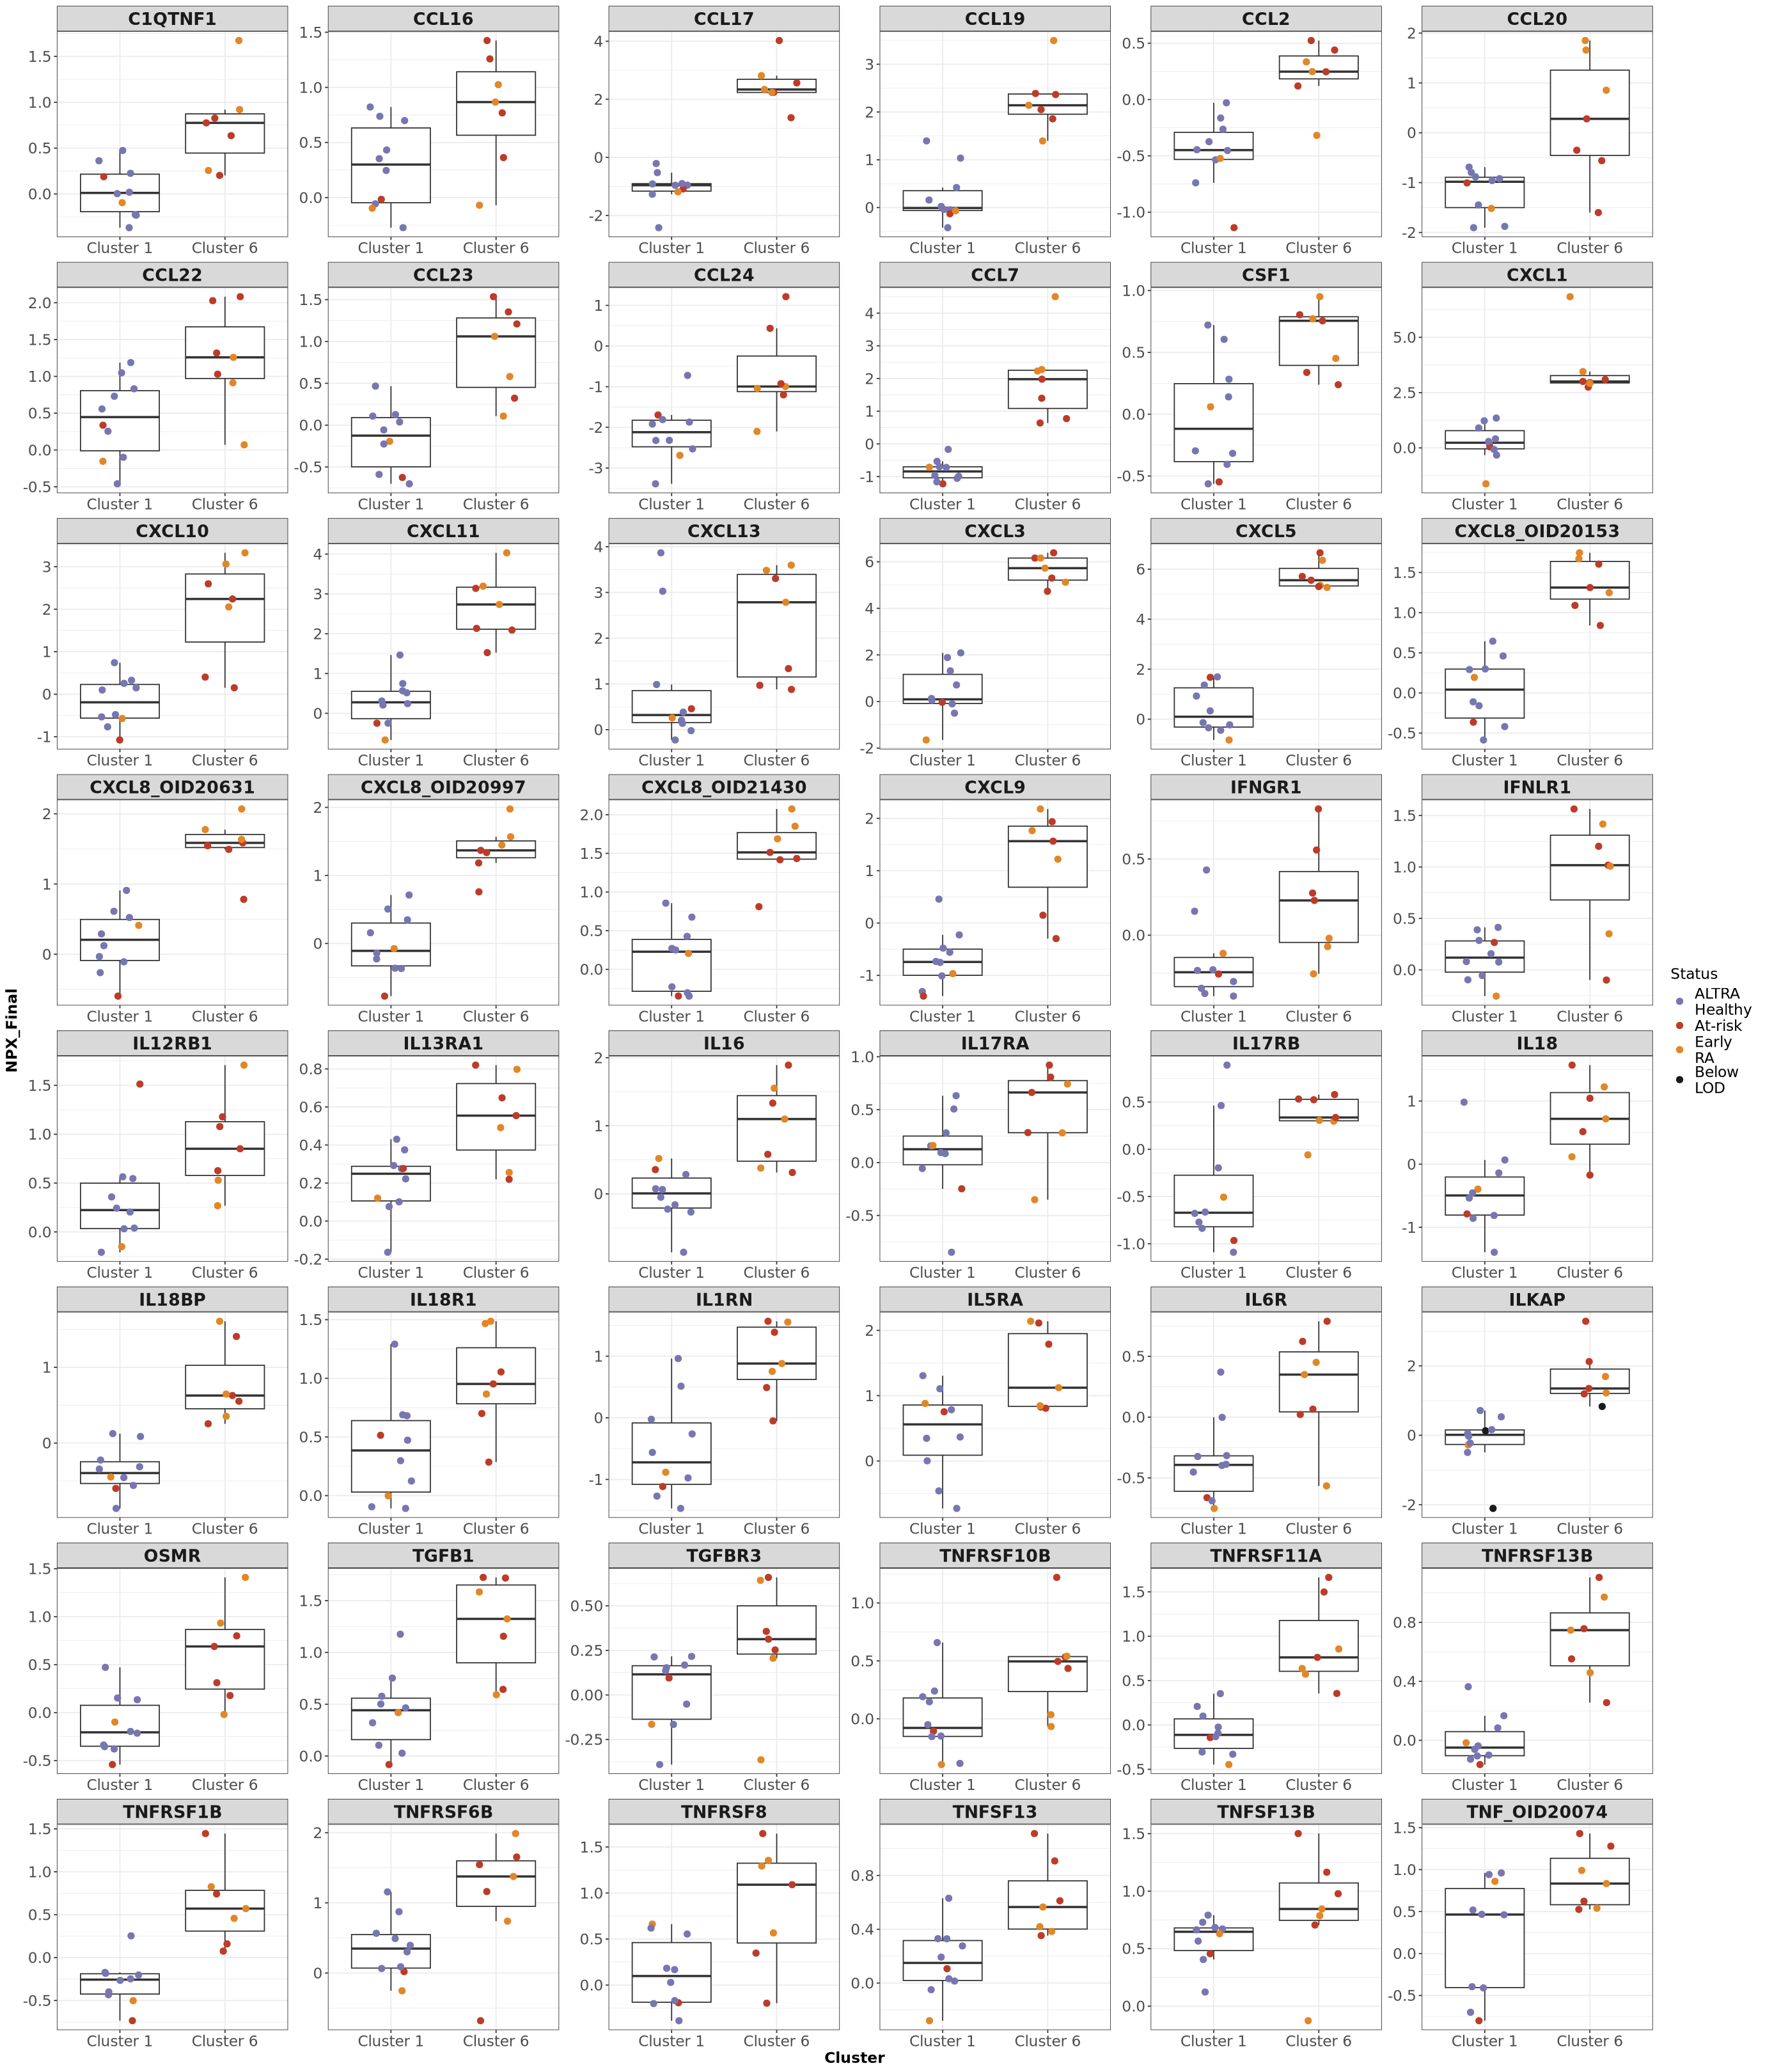

In [57]:
options(repr.plot.width = 23, repr.plot.height = 27) # default 7x7


ggplot(cyto, aes(x=Cluster, 
                 y=NPX_Final)) + 
    geom_boxplot(outlier.shape = NA) + # mask outliers as show up as duplicate dots
    geom_jitter(position = position_jitter(0.2), 
                size = 2.5,
                aes(colour=ifelse(NPX_Final >= LOD_Final, 
                                  Status_Xsec, 
                                  'below lod'))) +  
    facet_wrap(~as.factor(Assay), 
               scales = 'free', 
               ncol = 6) + 
    scale_colour_manual(breaks = c('ALTRA_healthy', 
                                   'at_risk',
                                   'early_RA',
                                   'below lod'), 
                        labels = c('ALTRA\nHealthy', 
                                   'At-risk',
                                   'Early\nRA',
                                   'Below\nLOD'), 
                        values = c('#7876B1FF',
                                   '#BC3C29FF',
                                   '#E18727FF',
                                   'grey10'), 
                        name = 'Status') + # NEJM colours
    scale_x_discrete(breaks = c('1', 
                                '6'),
                     labels = c('Cluster 1', 
                                'Cluster 6'), 
                     limits = c('1', 
                                '6')) + 
    theme_bw() + 
    guides(colour = guide_legend(byrow = TRUE)) + 
    theme (plot.title = element_text(size=14, face='bold', hjust=0.5), 
         #legend.position = c(0.85, 0.75),
         #legend.background = element_rect(colour = 'black', size = 0.5),
         legend.text = element_text(size=14), 
         legend.title = element_text(size=14),
         legend.spacing.y = unit(0.5, 'cm'),
         strip.text.x = element_text(size=16, face='bold'),
         axis.text.y = element_text(size=14),
         axis.text.x = element_text(size=14), 
         axis.title.y = element_text(size=14, face='bold'), 
         axis.title.x = element_text(size = 14, face = 'bold'))

#### Visualization: Figure boxplots

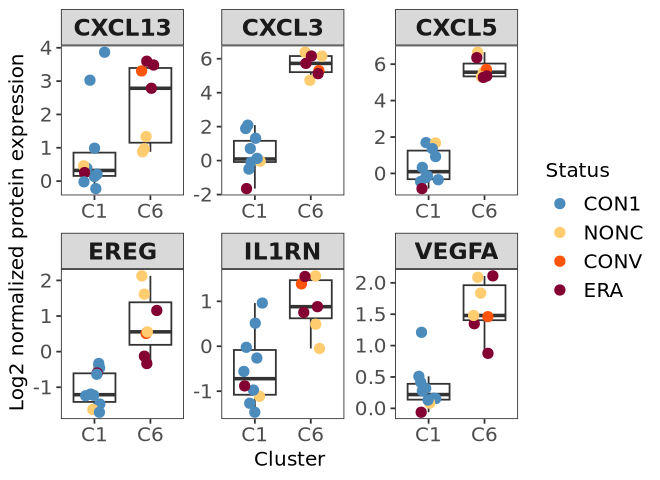

In [58]:
# CXCL13 = O43927
# CXCL3 = P19876
# VEGFA = P15692
# CXCL5 = P42830
# IL1RN = P18510
# EREG = O14944

#options(repr.plot.width = 5.5, repr.plot.height = 4) # default 7x7
options(repr.plot.width = 5.5, repr.plot.height = 4) # default 7x7

prots <- c('O43927', 'P19876', 'P15692', 'P42830', 'P18510', 'O14944')

p <- manuBoxplot(notClusteredDF, 
                 prots, 
                 3)

print(p)

In [59]:
ggsave(filename = 'C1vC6_DiffProts2_v2.pdf', 
       path = '/home/workspace/temp/output',
       p,
       device = 'pdf', 
       width = 5.5, 
       height = 4, 
       units = 'in')

In [ ]:
npx <- notClusteredDF %>%
    filter(UniProt %in% prots) %>%
    select(Assay, 
           sample.sampleKitGuid, 
           Cluster,
           NPX_Final) %>%
    arrange(Assay)

head(npx)

In [ ]:
out_npxMatrix <- paste0(
    "/home/workspace/temp/output/",
    Sys.Date(),
    "_NPX_Fig1D_matrix.csv"
)

write.csv(
    npx, 
    out_npxMatrix,
    row.names = TRUE
)

outFiles <- c(outFiles, out_npxMatrix)

#### Visualization: Heatmap of all inflammatory mediators
Regardless of whether they were significant in initial input comparisons or whether they were significant in re-analysis of donors in C1 vs C6

In [60]:
pattern <- c('TNF', 'IFN', 'OSM', 'TGF', 'FASL', 'CSF', 'LILRB', 'CXCL', 'CCL')


sig <- wcxC1C6df %>%
    filter(qval <= 0.05)


cyto <- notClusteredDF %>% # re-analysis
    filter(OlinkID %in% sig$OlinkID, 
           grepl(paste0(pattern, collapse = '|'), Assay) | 
           startsWith(Assay, 'IL'), 
           Assay != 'ILKAP')


cyto2 <- cyto %>%
    select(Cluster, 
           Status_Xsec,
           RAstatus,
           Subject_Sample, 
           sample.sampleKitGuid, 
           subject.subjectGuid, 
           Assay, 
           Assay_OID, 
           UniProt, 
           UniProt_OID, 
           OlinkID, 
           NPX_Final, 
           LOD_Final)


head(cyto2)
nrow(cyto2)

,Cluster,Status_Xsec,RAstatus,Subject_Sample,sample.sampleKitGuid,subject.subjectGuid,Assay,Assay_OID,UniProt,UniProt_OID,OlinkID,NPX_Final,LOD_Final
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,1,ALTRA_healthy,ALTRA_healthy,CU1101_KT04671,KT04671,CU1101,TNF_OID20074,TNF_OID20074,P01375,P01375_OID20074,OID20074,0.9410,-4.0164
2,1,ALTRA_healthy,ALTRA_healthy,CU1101_KT04671,KT04671,CU1101,CXCL8_OID20153,CXCL8_OID20153,P10145,P10145_OID20153,OID20153,-0.4191,-4.2989
3,1,ALTRA_healthy,ALTRA_healthy,CU1101_KT04671,KT04671,CU1101,CXCL5,CXCL5_OID20207,P42830,P42830_OID20207,OID20207,1.6917,-0.6726
4,1,ALTRA_healthy,ALTRA_healthy,CU1101_KT04671,KT04671,CU1101,TGFBR3,TGFBR3_OID20255,Q03167,Q03167_OID20255,OID20255,0.1362,-9.2413
5,1,ALTRA_healthy,ALTRA_healthy,CU1101_KT04671,KT04671,CU1101,TNFSF13B,TNFSF13B_OID20272,Q9Y275,Q9Y275_OID20272,OID20272,0.7292,-7.6764
6,1,ALTRA_healthy,ALTRA_healthy,CU1101_KT04671,KT04671,CU1101,CCL16,CCL16_OID20334,O15467,O15467_OID20334,OID20334,-0.0564,-7.9593


[1] 799

In [61]:
cyto3 <- clusterInfo %>%
    left_join(sigDEPs, by = 'Subject_Sample') %>%
    filter(Cluster %in% clusters_of_interest) %>%
    select(Cluster, 
           Status_Xsec,
           RAstatus,
           Subject_Sample, 
           sample.sampleKitGuid, 
           subject.subjectGuid, 
           Assay, 
           Assay_OID, 
           UniProt, 
           UniProt_OID, 
           OlinkID, 
           NPX_Final, 
           LOD_Final) %>%
    rename(sample.sampleKitGuid = sample.sampleKitGuid) %>%
    filter(grepl(paste0(pattern, collapse = '|'), Assay) | 
           startsWith(Assay, 'IL'), 
           Assay != 'ILKAP') %>%
    bind_rows(cyto2) %>%
    arrange(match(Cluster, c('1', 
                             '6')))


head(cyto3)
nrow(cyto3)

,Cluster,Status_Xsec,RAstatus,Subject_Sample,sample.sampleKitGuid,subject.subjectGuid,Assay,Assay_OID,UniProt,UniProt_OID,OlinkID,NPX_Final,LOD_Final
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,1,ALTRA_healthy,ALTRA_healthy,CU1101_KT04671,KT04671,CU1101,IL1B,IL1B_OID20427,P01584,P01584_OID20427,OID20427,-0.9849,-0.6099
2,1,ALTRA_healthy,ALTRA_healthy,CU1101_KT04671,KT04671,CU1101,CCL28,CCL28_OID20569,Q9NRJ3,Q9NRJ3_OID20569,OID20569,0.6088,-2.0101
3,1,ALTRA_healthy,ALTRA_healthy,CU1101_KT04671,KT04671,CU1101,IL7,IL7_OID20535,P13232,P13232_OID20535,OID20535,0.2795,-1.6518
4,1,ALTRA_healthy,ALTRA_healthy,CU1101_KT04671,KT04671,CU1101,CCL4,CCL4_OID20695,P13236,P13236_OID20695,OID20695,-0.5779,-8.7285
5,1,ALTRA_healthy,ALTRA_healthy,CU1101_KT04671,KT04671,CU1101,CCL11,CCL11_OID20668,P51671,P51671_OID20668,OID20668,-1.5727,-10.1139
6,1,ALTRA_healthy,ALTRA_healthy,CU1101_KT04671,KT04671,CU1101,CCL13,CCL13_OID20655,Q99616,Q99616_OID20655,OID20655,-0.9991,-9.1534


[1] 1343

,Cluster,Status
,<chr>,<chr>
1,1,ALTRA_healthy
2,1,ALTRA_healthy
3,1,ALTRA_healthy
4,1,non_converter
5,1,ALTRA_healthy
6,1,ALTRA_healthy


,CU1101_KT04671,CU1104_KT04905,CU1092_KT04652,CU1034_KT00420,CU1054_KT04115,CU1088_KT04633,CU1093_KT04625,CU1095_KT04624,CU1105_KT04908,CU1100_KT04659,CU1057_KT02177,SD1003_KT00114,CU1001_KT00070,SD1014_KT00778,SD1001_KT00120,SD1012_KT00777,CU1059_KT02140
IL1B,-0.8886518,-0.09052469,-0.7603153,0.8680014,-0.2322707,-1.1141216,-1.0024612,-1.63640701,-0.9798540,-0.7959882,1.195762,0.8824425,1.1379979,1.5013456,0.1903885,0.767945441,0.9567109
CCL28,-0.6182877,-0.85180391,-0.5564034,-0.4074945,-0.8485405,-0.5792474,-1.5812400,-0.04005695,-0.9223906,-0.4624893,1.306348,0.9648365,0.5069899,1.1481322,-0.1760330,0.971182023,2.1464988
IL7,-0.6912571,-0.58756804,-0.9898364,-0.6839504,-0.7950790,-1.4316275,-0.3688313,-0.75070726,-0.4129373,-0.9410806,1.484652,0.7996467,1.4766478,1.2018486,0.6485968,1.420020739,0.6214623
CCL4,-0.9751999,-0.84314259,-0.2130505,-0.8044017,-0.7013675,-0.3622874,-1.2120701,0.13557387,-0.6707393,-0.6020209,1.471678,0.2776960,0.5107485,0.9141654,0.1373092,0.233445516,2.7036634
CCL11,-1.4741088,-0.83750356,0.3930619,-0.8304245,-0.2960820,0.8299178,0.2612034,0.38043897,-1.5880564,-0.4221408,1.600684,0.7212582,1.5444782,-1.2459578,1.2270284,-0.006692764,-0.2571045
CCL13,-0.9175743,-0.62881155,-0.5688933,-0.8434585,-0.6341055,-1.1736106,-0.4261161,-0.73597461,-0.8250098,-0.6817514,1.805619,1.5555984,0.8950536,0.4573775,0.3216992,1.650328632,0.7496295


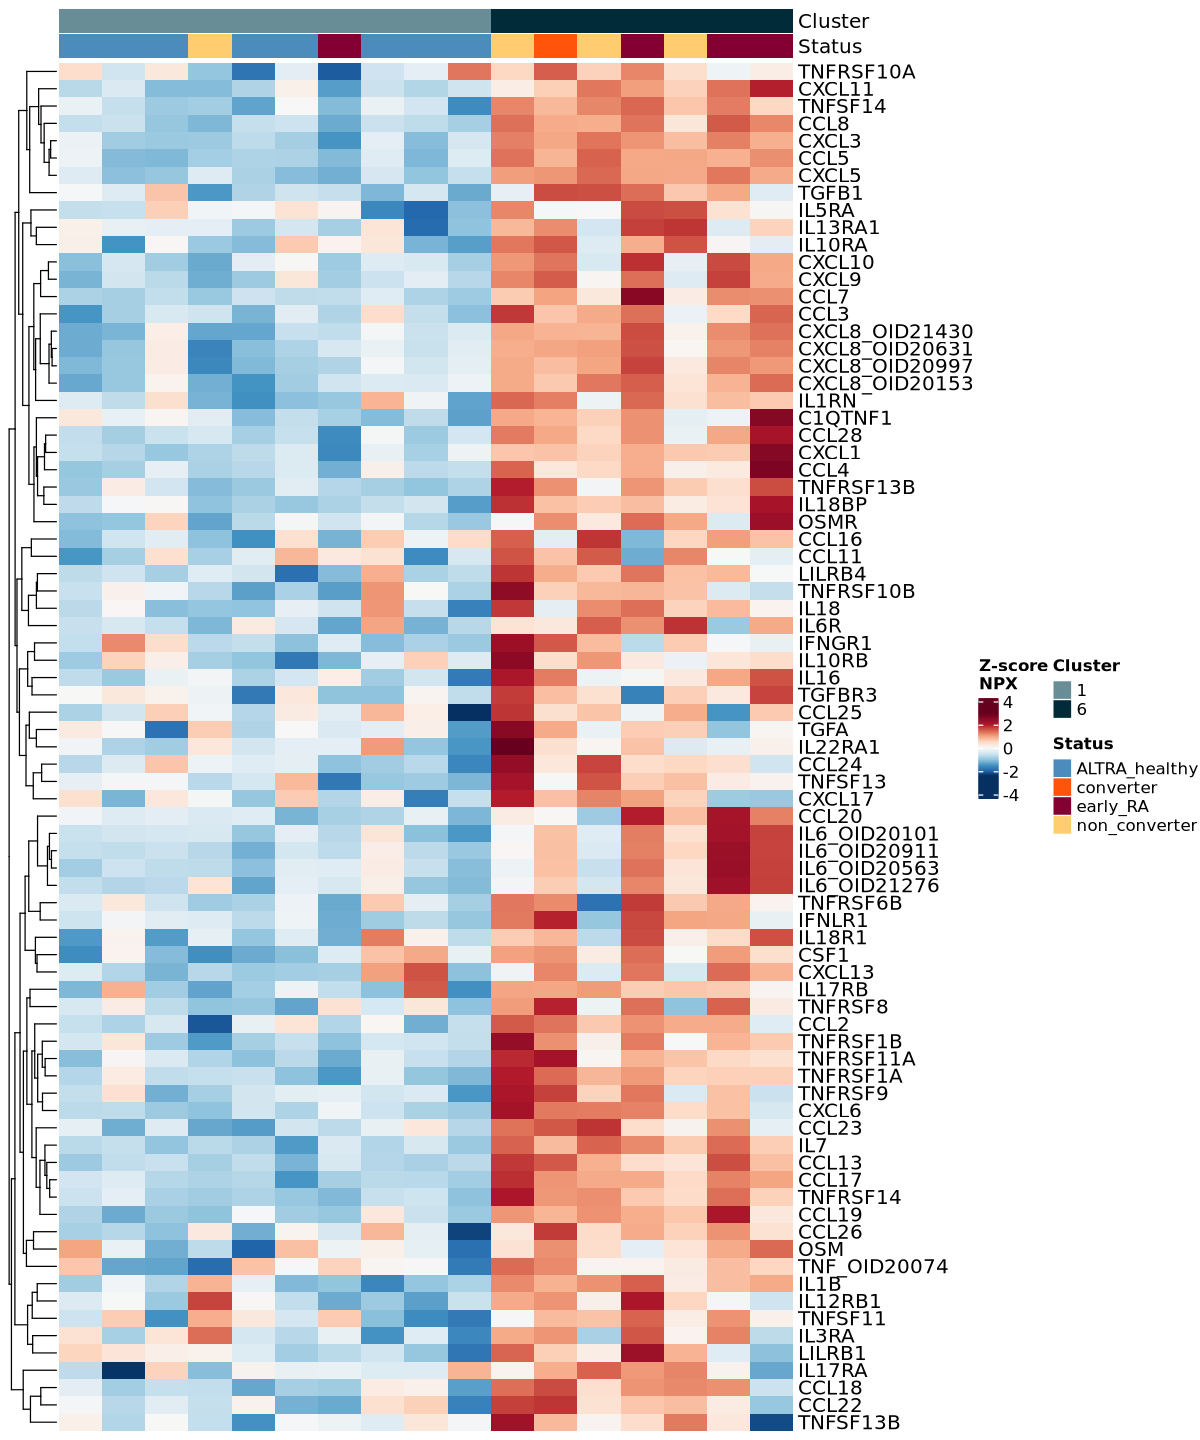

In [62]:
# Column annotations. Must be in same order as data matrix.
# As long as input order is preserved between annotation and matrix, it will be the same after the algorithm clusters the data

anno <- cyto3 %>% 
    distinct(Subject_Sample, .keep_all = T) # unique df

colAnn <- data.frame(Cluster = anno$Cluster,
                     Status = anno$RAstatus)

head(colAnn)


# Annotation colours
annotColours <- list(Cluster = c('1' = '#688D97',
                                 '6' = '#022B3A'),
                     Status = c('ALTRA_healthy' = '#4C8CBD',
                                'non_converter' = '#FFCD70', 
                                'converter' = '#FF540A',
                                'early_RA' = '#840032'))


# Annotation function
colHA <- HeatmapAnnotation(df = colAnn, 
                           col = annotColours)


# Standardized data matrix. Must be in same order as annotations.
DEP <- cyto3 %>%
    select(Subject_Sample, 
           Assay, 
           NPX_Final) %>%
    pivot_wider(names_from = Subject_Sample, 
                values_from = NPX_Final) %>%
    column_to_rownames(var = 'Assay') %>%
    drop_na() %>%
    as.matrix()

DEP <- t(scale(t(DEP)))

head(DEP)


# Set scale limits. Requires long format data
longDEP <- DEP %>%
    as.data.frame() %>%
    rownames_to_column(var = 'Assay') %>%
    pivot_longer(cols = !Assay, 
                 names_to = 'Subject_Sample', 
                 values_to = 'NPX', 
                 values_drop_na = TRUE)

limit <- range(longDEP$NPX)
limit <- c(ceiling(limit[1]), floor(limit[2]))
limit <- min(abs(limit))


# plot

options(repr.plot.width = 10, repr.plot.height = 12) # default 7x7

set.seed(543)

hm <- Heatmap(matrix = DEP, 
              col = colorRamp2(c(min(DEP), # min = -5.18
                                 seq(from = -1*limit, 
                                     to = limit, 
                                     length.out = 9),
                                 max(DEP)), # max = 8.02
                               rev(brewer.pal(n=11, name = 'RdBu'))),
              na_col = 'black',
              #rect_gp = gpar(col = "white", lwd = 0.5),
              name = 'Z-score\nNPX', 
              cluster_columns = FALSE,
              cluster_rows = TRUE,
              clustering_distance_rows = "euclidean",
              clustering_method_rows = "complete",
              clustering_distance_columns = "euclidean",
              clustering_method_columns = "complete",
              show_row_names = TRUE, 
              show_column_names = FALSE,
              column_km = 1,
              column_km_repeats = 100, 
              row_km = 1, 
              row_km_repeats = 100, 
              top_annotation = colHA)

hm <- draw(hm)

#### Visualization: Figure for inflammatory mediators heatmap

In [63]:
# Column annotations. Must be in same order as data matrix.
# As long as input order is preserved between annotation and matrix, it will be the same after the algorithm clusters the data

anno <- cyto3 %>% 
    distinct(Subject_Sample, .keep_all = T) # unique df

colAnn <- data.frame(Cluster = anno$Cluster,
                     Status = anno$RAstatus)

head(colAnn)


# Annotation colours
annotColours <- list(Cluster = c('1' = '#688D97',
                                 '6' = '#022B3A'),
                     Status = c('ALTRA_healthy' = '#4C8CBD',
                                'non_converter' = '#FFCD70', 
                                'converter' = '#FF540A',
                                'early_RA' = '#840032'))


# Annotation function
colHA <- HeatmapAnnotation(df = colAnn, 
                           col = annotColours)


# Standardized data matrix. Must be in same order as annotations.
DEP <- cyto3 %>%
    select(Subject_Sample, 
           Assay, 
           NPX_Final) %>%
    pivot_wider(names_from = Subject_Sample, 
                values_from = NPX_Final) %>%
    column_to_rownames(var = 'Assay') %>%
    drop_na() %>%
    as.matrix()

DEP <- t(scale(t(DEP)))

head(DEP)


# Set scale limits. Requires long format data
longDEP <- DEP %>%
    as.data.frame() %>%
    rownames_to_column(var = 'Assay') %>%
    pivot_longer(cols = !Assay, 
                 names_to = 'Subject_Sample', 
                 values_to = 'NPX', 
                 values_drop_na = TRUE)

limit <- range(longDEP$NPX)
limit <- c(ceiling(limit[1]), floor(limit[2]))
limit <- min(abs(limit))


# plot

options(repr.plot.width = 5, repr.plot.height = 3) # default 7x7

set.seed(543)

pdf('/home/workspace/temp/output/CytoChemo.pdf', 
    width = 4, 
    height = 3, 
    colormodel = 'cmyk')

hm <- Heatmap(matrix = DEP, 
              col = colorRamp2(c(min(DEP), # min = -5.18
                                 seq(from = -1*limit, 
                                     to = limit, 
                                     length.out = 9),
                                 max(DEP)), # max = 8.02
                               rev(brewer.pal(n=11, name = 'RdBu'))),
              na_col = 'black',
              #rect_gp = gpar(col = "white", lwd = 0.5),
              name = 'Z-score\nNPX', 
              cluster_columns = FALSE,
              cluster_rows = TRUE,
              clustering_distance_rows = "euclidean",
              clustering_method_rows = "complete",
              clustering_distance_columns = "euclidean",
              clustering_method_columns = "complete",
              show_row_names = FALSE, 
              show_column_names = FALSE,
              column_km = 1,
              column_km_repeats = 100, 
              row_km = 1, 
              row_km_repeats = 100, 
              top_annotation = colHA)

hm <- draw(hm)

dev.off()

,Cluster,Status
,<chr>,<chr>
1,1,ALTRA_healthy
2,1,ALTRA_healthy
3,1,ALTRA_healthy
4,1,non_converter
5,1,ALTRA_healthy
6,1,ALTRA_healthy


,CU1101_KT04671,CU1104_KT04905,CU1092_KT04652,CU1034_KT00420,CU1054_KT04115,CU1088_KT04633,CU1093_KT04625,CU1095_KT04624,CU1105_KT04908,CU1100_KT04659,CU1057_KT02177,SD1003_KT00114,CU1001_KT00070,SD1014_KT00778,SD1001_KT00120,SD1012_KT00777,CU1059_KT02140
IL1B,-0.8886518,-0.09052469,-0.7603153,0.8680014,-0.2322707,-1.1141216,-1.0024612,-1.63640701,-0.9798540,-0.7959882,1.195762,0.8824425,1.1379979,1.5013456,0.1903885,0.767945441,0.9567109
CCL28,-0.6182877,-0.85180391,-0.5564034,-0.4074945,-0.8485405,-0.5792474,-1.5812400,-0.04005695,-0.9223906,-0.4624893,1.306348,0.9648365,0.5069899,1.1481322,-0.1760330,0.971182023,2.1464988
IL7,-0.6912571,-0.58756804,-0.9898364,-0.6839504,-0.7950790,-1.4316275,-0.3688313,-0.75070726,-0.4129373,-0.9410806,1.484652,0.7996467,1.4766478,1.2018486,0.6485968,1.420020739,0.6214623
CCL4,-0.9751999,-0.84314259,-0.2130505,-0.8044017,-0.7013675,-0.3622874,-1.2120701,0.13557387,-0.6707393,-0.6020209,1.471678,0.2776960,0.5107485,0.9141654,0.1373092,0.233445516,2.7036634
CCL11,-1.4741088,-0.83750356,0.3930619,-0.8304245,-0.2960820,0.8299178,0.2612034,0.38043897,-1.5880564,-0.4221408,1.600684,0.7212582,1.5444782,-1.2459578,1.2270284,-0.006692764,-0.2571045
CCL13,-0.9175743,-0.62881155,-0.5688933,-0.8434585,-0.6341055,-1.1736106,-0.4261161,-0.73597461,-0.8250098,-0.6817514,1.805619,1.5555984,0.8950536,0.4573775,0.3216992,1.650328632,0.7496295


png 
  2

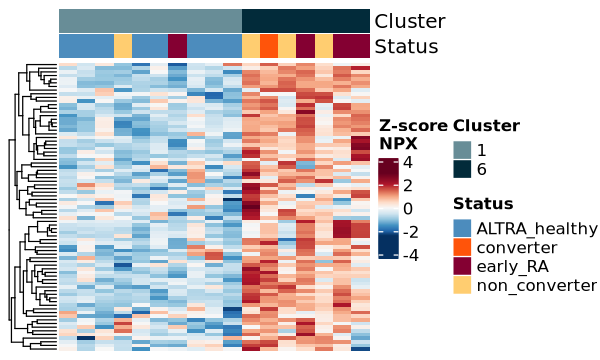

In [64]:
hm

In [65]:
out_cyto_DEP <- paste0(
    "/home/workspace/temp/output/",
    Sys.Date(),
    "_Cytokine_DEP_Cluster_Matrix.csv"
)

write.csv(
    DEP, 
    out_cyto_DEP,
    row.names = TRUE
)

outFiles <- c(outFiles, out_cyto_DEP)

## Store results in HISE

In [82]:
study_space_uuid <- '223de760-9624-45bd-aefe-ca24c75b1800'

title <- paste('ALTRA Olink k-means Clustering on HC1 | ARI and HC1 | ERA', Sys.Date())

In [83]:
search_id <- ids::proquint(n_words = 3)
search_id

[1] "tadof-donub-vakag"

In [84]:
in_list <- list(a1_uuid, ari_dap_uuid, a2_uuid, era_dap_uuid, meta_uuid)

In [85]:
out_list <- list(outFiles)

In [93]:
uploadFiles(
    files = outFiles,
    studySpaceId = study_space_uuid,
    title = title,
    inputFileIds = in_list,
    destination = search_id,
    store = "project",
    doPrompt = FALSE
)

$Message
[1] "General Okay-ness"

$VisualizationId
[1] "00000000-0000-0000-0000-000000000000"

$AbstractionId
[1] "00000000-0000-0000-0000-000000000000"

$TraceId
[1] "9f6ddc0f-f5df-4b4d-b07a-bfa0e4dabbf4"

$ProcessId
[1] "e880a447-e566-4296-a814-e9a1bb225c96"

$WorkflowId
[1] "2d68da7c-f07a-4fc7-bd52-e13db804eb3c"

$FileIds
$FileIds[[1]]
[1] "fcfcbd9e-ae55-468f-8b79-2d165c56933f"

$FileIds[[2]]
[1] "4488b361-398c-496d-be25-0a62bd8393f2"

$FileIds[[3]]
[1] "50882fdc-46c3-4825-9aa6-3769d73f09fa"

$FileIds[[4]]
[1] "1154ac87-e298-41cf-951c-0c30bfa4c974"

$FileIds[[5]]
[1] "bed34680-a826-442a-92ef-0da3f98b8793"

In [94]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/olink/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] RColorBrewer_1.1-3    circlize_0.4.16       ComplexHeatmap_2.18.0
 [4] cluster_2.1.6         factoextra_1.0.7      ggrepel_0.9.5        
 [7] ggplot2_3.5.1         qvalue_2.34.0         forcats_1.0.0        
[10] tibble_3.2.1          tidyr_1.3.1           dplyr_1.1.4          
[13] purrr_1.0.2